# Charts

This notebook only reads the clean files made by the other three notebooks and saves the charts into `charts/`. Each company keeps the same colour and marker in every chart.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

CLEAN = "data/clean/"
OUT = "charts/"

# one fixed colour per company everywhere, so a reader can follow a company across charts
COLOR = {"Balrampur": "#2a78d6", "Triveni": "#eb6834", "Bajaj Hindusthan": "#1baf7a"}
MARK = {"Balrampur": "o", "Triveni": "s", "Bajaj Hindusthan": "^"}
INK, INK2, GRID, BG = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
})

In [2]:
firms = pd.read_csv(CLEAN + "firms.csv").sort_values("fy")
eth = pd.read_csv(CLEAN + "ethanol.csv")


def short(fy):
    # 2016-17 becomes FY17 so the axis stays readable
    return "FY" + fy[-2:]


def by_company(col, title, ylabel, fname, fmt="{:.0f}"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for name, g in firms.groupby("company"):
        x = [short(f) for f in g["fy"]]
        ax.plot(x, g[col], color=COLOR[name], lw=2, marker=MARK[name], ms=6, label=name)
        # name and last value at the line end, so the chart reads without the legend
        ax.annotate(f"{name}  " + fmt.format(g[col].iloc[-1]), (x[-1], g[col].iloc[-1]),
                    xytext=(8, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
    ax.set_title(title, loc="left", fontsize=12, color=INK)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
    fig.tight_layout()
    fig.savefig(OUT + fname, dpi=150, bbox_inches="tight")
    return fig

Payable days for each company, year by year.

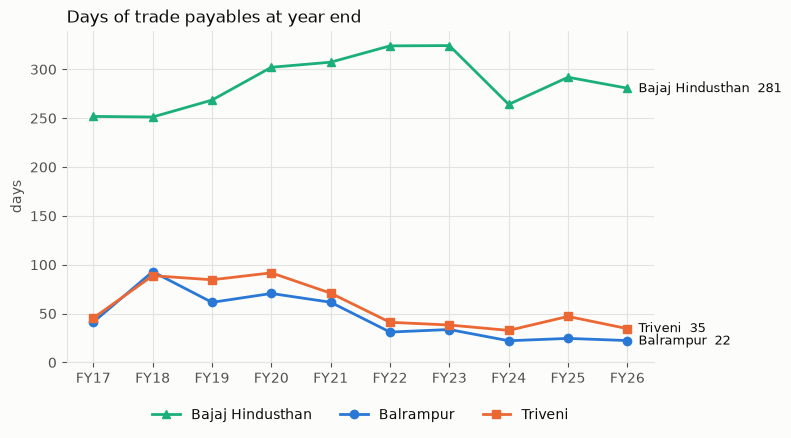

In [3]:
fig1 = by_company("payable_days", "Days of trade payables at year end", "days", "payable_days.png")

How much of each company's sugar and distillery revenue came from the distillery.

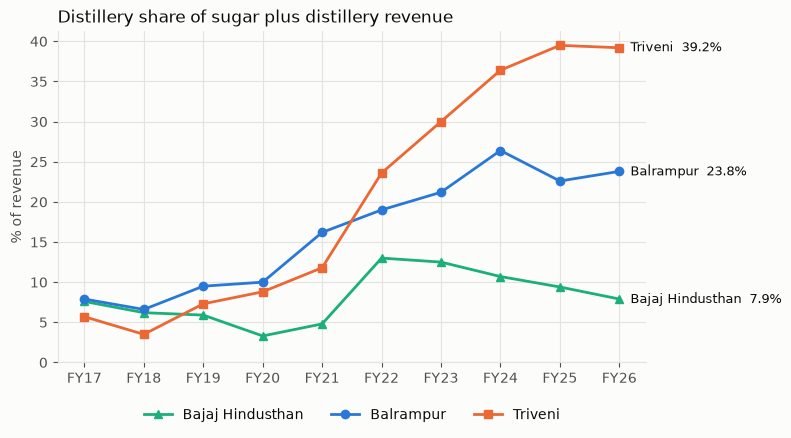

In [4]:
fig2 = by_company("distillery_share", "Distillery share of sugar plus distillery revenue", "% of revenue",
                  "distillery_share.png", "{:.1f}%")

The two together, one dot per company per year.

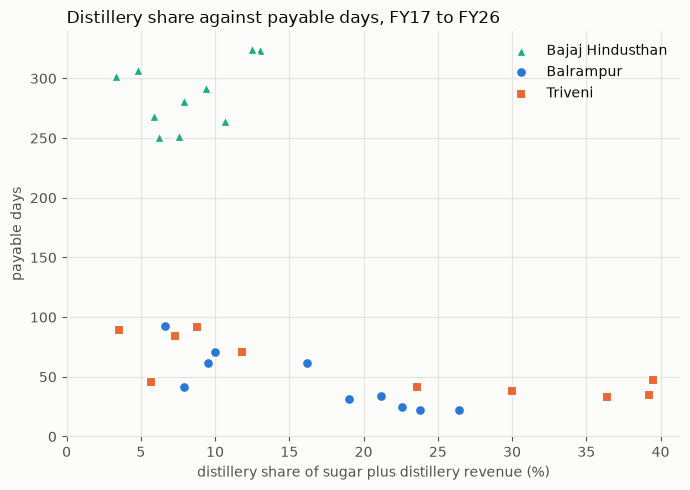

In [5]:
# all 30 company-years in one picture, the main relationship this study is about
fig3, ax = plt.subplots(figsize=(7, 5))
for name, g in firms.groupby("company"):
    ax.scatter(g["distillery_share"], g["payable_days"], s=60, color=COLOR[name], marker=MARK[name],
               edgecolor=BG, linewidth=1.5, label=name)
ax.set_title("Distillery share against payable days, FY17 to FY26", loc="left", fontsize=12)
ax.set_xlabel("distillery share of sugar plus distillery revenue (%)")
ax.set_ylabel("payable days")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
fig3.tight_layout()
fig3.savefig(OUT + "days_vs_share.png", dpi=150, bbox_inches="tight")

The national side, ethanol supplied to the oil companies split into the sugar side and grain or maize.

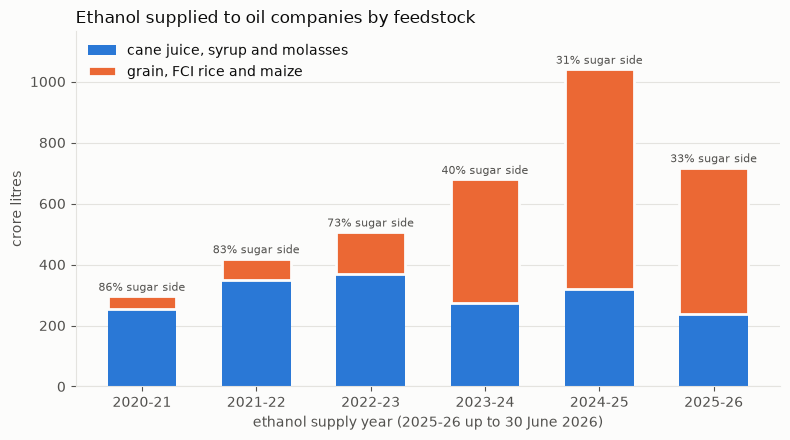

In [6]:
# national ethanol supply split into the sugar side and everything else
eth["other"] = eth["total"] - eth["sugar_route"]
fig4, ax = plt.subplots(figsize=(8, 4.5))
x = eth["esy"]
ax.bar(x, eth["sugar_route"], color="#2a78d6", width=0.6, label="cane juice, syrup and molasses")
ax.bar(x, eth["other"], bottom=eth["sugar_route"], color="#eb6834", width=0.6,
       edgecolor=BG, linewidth=2, label="grain, FCI rice and maize")
for xi, s, t in zip(x, eth["sugar_route_share"], eth["total"]):
    ax.annotate(f"{s:.0f}% sugar side", (xi, t), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8, color=INK2)
ax.set_title("Ethanol supplied to oil companies by feedstock", loc="left", fontsize=12)
ax.set_ylabel("crore litres")
ax.set_ylim(0, eth["total"].max() * 1.12)
ax.set_xlabel("ethanol supply year (2025-26 up to 30 June 2026)")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
fig4.tight_layout()
fig4.savefig(OUT + "ethanol_mix.png", dpi=150, bbox_inches="tight")